# Подтверждение цифр качества из README и DESIGN

Источник - `validation.json`, посчитанный `validate.py` на полном датасете RBA
(паспорт прогона ниже). Ноутбук только рендерит артефакт: тяжёлый шаг выполнен
один раз и воспроизводится заново парой команд:

```sh
make -C training validate    # полный датасет (сперва make data-rba), пишет validation.json
make -C training notebook    # пересобрать и исполнить этот ноутбук из analysis.py
```

Каждое утверждение доков сверяется с измеренным значением программно - таблица
вердиктов в конце раздела 1.

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt

V = json.loads(pathlib.Path("validation.json").read_text())
meta, fx = V["meta"], V["fixture_eval"]
sc, lk = V["split_comparison"], V["leakage_contrast"]

print(f"датасет: {meta['dataset_rows']:,} строк, attack_rate={meta['attack_rate']:.4f}")
print(f"lightgbm {meta['lightgbm_version']} | seed={meta['seed']} threads={meta['threads']} "
      f"| коммит {meta['commit']} | {meta['created_utc']}")
print(f"модель: {fx['model']} @ sha256 {fx['model_sha256_16']}")
print(f"длительности, c: {meta['durations_s']}")

датасет: 31,269,264 строк, attack_rate=0.0990
lightgbm 4.6.0 | seed=708 threads=8 | коммит 7bde31b | 2026-06-10T08:29:04Z
модель: model.txt @ sha256 30957f34ce18bdde
длительности, c: {'load': 37.1, 'fixture_eval': 1.0, 'split_comparison': 21.2, 'leakage_contrast': 14.1}


## 1. Утверждения доков против измеренного

Сверка сплита и модели: строки восстановленного holdout совпадают с
`holdout.csv` оригинального обучения, предсказания - с `ref_raw.csv`. Это
доказывает, что метрики ниже посчитаны на том же сплите той же моделью, чьи
эталоны проверяет harness паритета на Go.

In [2]:
ck = fx["checks"]
top_feat, top_share = max(fx["gain_share"].items(), key=lambda kv: kv[1])
rows = [
    ("README: ROC-AUC 0.703",
     f"{fx['roc_auc']:.4f}", round(fx["roc_auc"], 3) == 0.703),
    ("README: ни один признак не доминирует",
     f"max gain {top_share:.0%} ({top_feat})", top_share < 0.5),
    ("DESIGN: частоты страны/ASN читают метку - ROC-AUC 0.89 против 0.70",
     f"{lk['roc_auc']:.3f} против {fx['roc_auc']:.3f}",
     round(lk["roc_auc"], 2) == 0.89 and round(fx["roc_auc"], 2) == 0.70),
    ("DESIGN: на частоты приходится 97.7% gain",
     f"{lk['freq_gain_share']:.1%}", abs(lk["freq_gain_share"] - 0.977) < 0.01),
    ("DESIGN: временной сплит ниже случайного по ROC-AUC и lift",
     f"ROC {sc['temporal']['roc_auc']:.3f}<{sc['random']['roc_auc']:.3f}, "
     f"lift {sc['temporal']['lift']:.2f}<{sc['random']['lift']:.2f}",
     sc["temporal"]["roc_auc"] < sc["random"]["roc_auc"]
     and sc["temporal"]["lift"] < sc["random"]["lift"]),
    ("сплит тот же: строки holdout совпали с holdout.csv",
     f"{ck.get('holdout_rows_matched')}/{ck.get('holdout_rows_total')}",
     ck.get("holdout_rows_total") is not None
     and ck.get("holdout_rows_matched") == ck.get("holdout_rows_total")),
    ("модель та же: maxD против ref_raw.csv",
     str(ck.get("ref_raw_max_abs_diff")),
     ck.get("ref_raw_max_abs_diff", 1.0) < 1e-9),
]
w = max(len(r[0]) for r in rows)
for claim, measured, ok in rows:
    print(f"{'OK ' if ok else 'РАСХОЖДЕНИЕ'}  {claim:<{w}}  | {measured}")

OK   README: ROC-AUC 0.703                                               | 0.7032
OK   README: ни один признак не доминирует                               | max gain 33% (secs_since_last)
OK   DESIGN: частоты страны/ASN читают метку - ROC-AUC 0.89 против 0.70  | 0.892 против 0.703
OK   DESIGN: на частоты приходится 97.7% gain                            | 97.7%
OK   DESIGN: временной сплит ниже случайного по ROC-AUC и lift           | ROC 0.682<0.697, lift 1.69<1.90
OK   сплит тот же: строки holdout совпали с holdout.csv                  | 50000/50000
OK   модель та же: maxD против ref_raw.csv                               | 0.0


## 2. Выгруженная модель на holdout 50000

Тот же детерминированный сплит, что в `train.py` (perm от seed): метки holdout
восстановлены из полного датасета. `margin>0` - дефолтная рабочая точка
сервиса, консервативная при базе ~10%: почти всё одобряется, отклонения
точные, но recall крошечный. Реальную точку выбирают по целевому FPR/recall на
кривых.

holdout: n=50,000 атак=4,963 base=0.0993
ROC-AUC=0.7032  PR-AUC=0.1900  lift=1.91
margin>0: precision=0.9 recall=0.0036 отклонено 20/50000


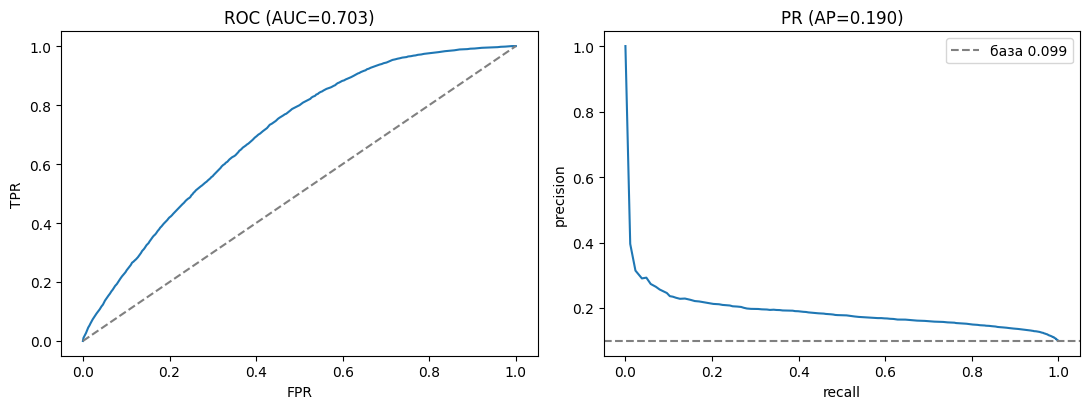

In [3]:
print(f"holdout: n={fx['n']:,} атак={fx['positives']:,} base={fx['base_rate']:.4f}")
print(f"ROC-AUC={fx['roc_auc']:.4f}  PR-AUC={fx['pr_auc']:.4f}  lift={fx['lift']:.2f}")
print(f"margin>0: precision={fx['margin0_precision']} recall={fx['margin0_recall']} "
      f"отклонено {fx['margin0_declined']}/{fx['n']}")

roc, pr = fx["roc_curve"], fx["pr_curve"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(roc["fpr"], roc["tpr"])
ax[0].plot([0, 1], [0, 1], "--", c="gray")
ax[0].set(title=f"ROC (AUC={fx['roc_auc']:.3f})", xlabel="FPR", ylabel="TPR")
ax[1].plot(pr["recall"], pr["precision"])
ax[1].axhline(fx["base_rate"], ls="--", c="gray", label=f"база {fx['base_rate']:.3f}")
ax[1].set(title=f"PR (AP={fx['pr_auc']:.3f})", xlabel="recall", ylabel="precision")
ax[1].legend()
plt.tight_layout()
plt.show()

## 3. Gain по признакам: ни один не доминирует

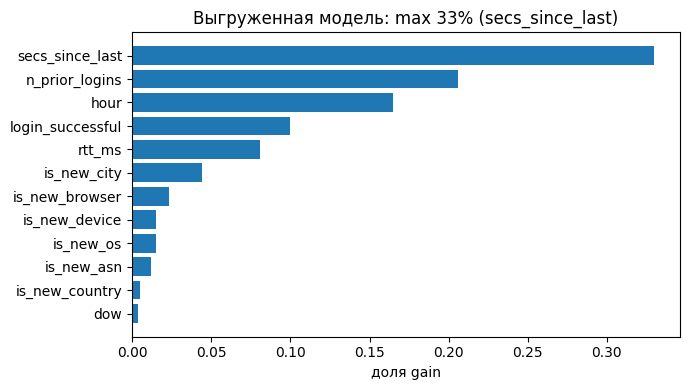

In [4]:
gs = dict(sorted(fx["gain_share"].items(), key=lambda kv: kv[1]))
plt.figure(figsize=(7, 4))
plt.barh(list(gs), list(gs.values()))
plt.xlabel("доля gain")
plt.title(f"Выгруженная модель: max {top_share:.0%} ({top_feat})")
plt.tight_layout()
plt.show()

## 4. Случайный против временного сплита

Одинаковое обучение (те же `TRAIN_PARAMS`, подвыборки одного размера),
меняется только сплит. Временной - обучение до 85-го перцентиля времени, тест
после: режим "предсказываем будущее" с дрейфом доли атак.

**PR-AUC между сплитами не сравнивать**: average precision механически растёт
с base rate, а у позднего теста доля атак выше - абсолютная PR-AUC временного
сплита может оказаться выше при худшей модели. Сравнимая величина -
**lift = PR-AUC / base** (и ROC-AUC, который от базы не зависит).

In [5]:
print(f"граница: {sc['temporal_cutoff'][:10]} | "
      f"attack_rate {sc['attack_rate_early']:.4f} -> {sc['attack_rate_late']:.4f}")
print(f"{'сплит':10s} {'ROC-AUC':>8s} {'PR-AUC':>7s} {'base':>7s} {'lift':>6s}")
for label, key in (("случайный", "random"), ("временной", "temporal")):
    r = sc[key]
    print(f"{label:10s} {r['roc_auc']:8.4f} {r['pr_auc']:7.4f} {r['base_rate']:7.4f} {r['lift']:6.2f}")

граница: 2021-01-05 | attack_rate 0.0957 -> 0.1178
сплит       ROC-AUC  PR-AUC    base   lift
случайный    0.6974  0.1874  0.0988   1.90
временной    0.6816  0.2002  0.1182   1.69


## 5. Контраст утечки: почему частоты страны и ASN выброшены

Метка `Is Attack IP` выводится из IP; страна и ASN - тоже из IP. Их глобальная
частота читает метку почти напрямую: качество подскакивает, но почти весь gain
уходит в два частотных признака - коды причин такой модели для adverse-action
бессмысленны. Поведенческая модель (раздел 2) честнее при меньшем ROC-AUC.

+country_freq, +asn_freq: ROC-AUC=0.8924 (честная 0.7032), доля gain у частот 97.7%


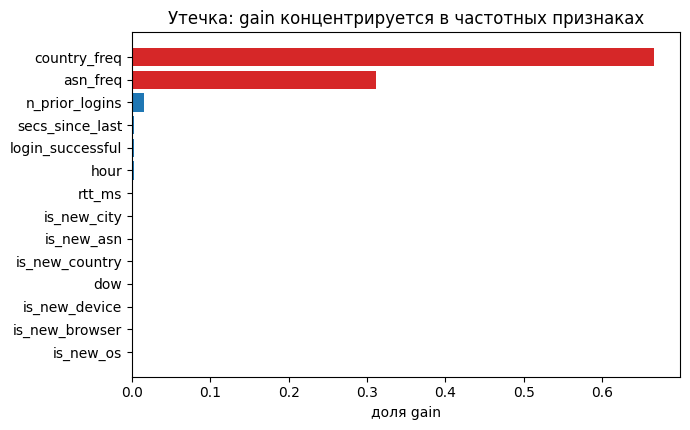

In [6]:
print(f"+country_freq, +asn_freq: ROC-AUC={lk['roc_auc']:.4f} "
      f"(честная {fx['roc_auc']:.4f}), доля gain у частот {lk['freq_gain_share']:.1%}")
gl = dict(sorted(lk["gain_share"].items(), key=lambda kv: kv[1]))
plt.figure(figsize=(7, 4.4))
plt.barh(list(gl), list(gl.values()),
         color=["C3" if k.endswith("_freq") else "C0" for k in gl])
plt.xlabel("доля gain")
plt.title("Утечка: gain концентрируется в частотных признаках")
plt.tight_layout()
plt.show()

## Итог

- Цифры README/DESIGN сведены с данными программно (раздел 1): качество
  выгруженной модели подтверждено на том же сплите той же моделью.
- Временной сплит ниже случайного по ROC и lift - дрейф и режим
  "предсказываем будущее"; абсолютная PR-AUC между сплитами несравнима.
- Утечка через глобальные частоты воспроизведена и показана как концентрация
  gain - обоснование выбора признаков в DESIGN, данными.